In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ayush2222/structured-bgl-logs-csv/BGL.log_structured.csv


In [2]:
import pandas as pd

print("Loading the FULL massive 4-million-row dataset with all columns...")

# We just add on_bad_lines='skip' so the broken row at line 5000 doesn't throw a red error
df = pd.read_csv("/kaggle/input/datasets/ayush2222/structured-bgl-logs-csv/BGL.log_structured.csv", on_bad_lines='skip')

print(f"Loaded {len(df)} rows flawlessly with all {len(df.columns)} columns")


Loading the FULL massive 4-million-row dataset with all columns...
Loaded 4188777 rows flawlessly with all 14 columns


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4188777 entries, 0 to 4188776
Data columns (total 14 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   LineId         int64 
 1   Label          object
 2   Timestamp      int64 
 3   Date           object
 4   Node           object
 5   Time           object
 6   NodeRepeat     object
 7   Type           object
 8   Component      object
 9   Level          object
 10  Content        object
 11  EventId        object
 12  EventTemplate  object
 13  ParameterList  object
dtypes: int64(2), object(12)
memory usage: 447.4+ MB


In [4]:
df.describe()

,LineId,Timestamp
count,4.188777e+06,4.188777e+06
mean,2.094389e+06,1.122735e+09
std,1.209196e+06,4.146252e+06
min,1.000000e+00,1.117839e+09
25%,1.047195e+06,1.119803e+09
50%,2.094389e+06,1.121308e+09
75%,3.141583e+06,1.125084e+09
max,4.188777e+06,1.132324e+09


In [5]:
df.head()

,LineId,Label,Timestamp,Date,Node,Time,NodeRepeat,Type,Component,Level,Content,EventId,EventTemplate,ParameterList
0,1,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.363779,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,3aa50e45,instruction cache parity error corrected,[]
1,2,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.527847,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,3aa50e45,instruction cache parity error corrected,[]
2,3,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.675872,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,3aa50e45,instruction cache parity error corrected,[]
3,4,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.823719,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,3aa50e45,instruction cache parity error corrected,[]
4,5,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.982731,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,3aa50e45,instruction cache parity error corrected,[]


In [6]:
df.sample(10)

,LineId,Label,Timestamp,Date,Node,Time,NodeRepeat,Type,Component,Level,Content,EventId,EventTemplate,ParameterList
2724224,2724225,-,1122256988,2005.07.24,R03-M0-NB-C:J17-U01,2005-07-24-19.03.08.776268,R03-M0-NB-C:J17-U01,RAS,KERNEL,INFO,generating core.13120,070de4aa,generating <*>,['core.13120']
2916238,2916239,-,1123030809,2005.08.02,R00-M0-NA,2005-08-02-18.00.09.815713,R00-M0-NA,NaN,DISCOVERY,INFO,Node card VPD check: U11 node in processor car...,79e9d62d,Node card VPD check <*> node in processor card...,"['U11', 'J17 do not match. VPD ecid 075B04E41D..."
3843324,3843325,-,1131061880,2005.11.03,R65-M1-N3-C:J09-U01,2005-11-03-15.51.20.489915,R65-M1-N3-C:J09-U01,RAS,KERNEL,INFO,iar 00106568 dear 045e143c,1b700d02,iar <*> dear <*>,"['00106568', '045e143c']"
92379,92380,-,1117988291,2005.06.05,R33-M0-N4-C:J07-U01,2005-06-05-09.18.11.620870,R33-M0-N4-C:J07-U01,RAS,KERNEL,INFO,generating core.3062,070de4aa,generating <*>,['core.3062']
3719803,3719804,-,1131058139,2005.11.03,R64-M0-N4-C:J03-U01,2005-11-03-14.48.59.957366,R64-M0-N4-C:J03-U01,RAS,KERNEL,INFO,iar 001061dc dear 0244c25c,1b700d02,iar <*> dear <*>,"['001061dc', '0244c25c']"
598807,598808,-,1118770619,2005.06.14,R27-M0-N0-C:J07-U01,2005-06-14-10.36.59.142071,R27-M0-N0-C:J07-U01,RAS,KERNEL,FATAL,program interrupt: fp cr field .............0,86983ded,<*> interrupt <*>,"['program', 'fp cr field .............0']"
3145389,3145390,-,1125083636,2005.08.26,R65-M1-N2-C:J15-U01,2005-08-26-12.13.56.460098,R65-M1-N2-C:J15-U01,RAS,KERNEL,INFO,iar 003a9254 dear 00f05448,1b700d02,iar <*> dear <*>,"['003a9254', '00f05448']"
4059999,4060000,-,1131474280,2005.11.08,R62-M0-NB-C:J13-U11,2005-11-08-10.24.40.601346,R62-M0-NB-C:J13-U11,RAS,KERNEL,INFO,24594126 floating point alignment exceptions,2d848ea7,floating point <*>,[]
773403,773404,-,1118783535,2005.06.14,R22-M0-NF-C:J02-U11,2005-06-14-14.12.15.099187,R22-M0-NF-C:J02-U11,RAS,KERNEL,INFO,generating core.75,070de4aa,generating <*>,['core.75']
2753630,2753631,-,1122430832,2005.07.26,R25-M0-ND-C:J06-U01,2005-07-26-19.20.32.025424,R25-M0-ND-C:J06-U01,RAS,KERNEL,INFO,generating core.52506,070de4aa,generating <*>,['core.52506']


In [7]:
df.shape

(4188777, 14)

In [8]:
df['Time'][0]

'2005-06-03-15.42.50.363779'

In [9]:
df['Time'][4188776]

'2005-11-18-06.28.04.751930'

In [10]:
print(df["Time"].dtype)

object


In [11]:
# Providing the exact blueprint of the supercomputer's strange time format
df["Time"] = pd.to_datetime(df["Time"], format="%Y-%m-%d-%H.%M.%S.%f", errors="coerce")

In [12]:
print(df["Time"].dtype)
print(df["Time"].min(), df["Time"].max())

datetime64[ns]
2005-06-03 15:42:50.363779 2005-11-18 06:28:04.751930


In [13]:
print(df.columns)

Index(['LineId', 'Label', 'Timestamp', 'Date', 'Node', 'Time', 'NodeRepeat',
       'Type', 'Component', 'Level', 'Content', 'EventId', 'EventTemplate',
       'ParameterList'],
      dtype='object')


In [14]:
df = df.drop(columns=["LineId", "Timestamp", "Date", "NodeRepeat"])

In [15]:
print(df.isna().sum())

Label                 0
Node              89048
Time                  0
Type             100143
Component             0
Level                 0
Content               0
EventId               0
EventTemplate         0
ParameterList         0
dtype: int64


In [16]:
df["Node"] = df["Node"].fillna("UNKNOWN")
df["Type"] = df["Type"].fillna("UNKNOWN")
print(df.isna().sum())

Label            0
Node             0
Time             0
Type             0
Component        0
Level            0
Content          0
EventId          0
EventTemplate    0
ParameterList    0
dtype: int64


In [17]:
df = df.sort_values("Time")

In [18]:
print("\nLabel distribution:")
print(df["Label"].value_counts(normalize=True))

print("\nLevel distribution:")
print(df["Level"].value_counts(normalize=True))

print("\nComponent distribution:")
print(df["Component"].value_counts(normalize=True))

print("\nUnique Nodes:", df["Node"].nunique())

print("\nUnique EventId:", df["EventId"].nunique())


Label distribution:
Label
-            9.249826e-01
KERNDTLB     3.646005e-02
KERNSTOR     1.515717e-02
KERNMNTF     6.961459e-03
KERNTERM     5.571555e-03
APPSEV       5.439296e-03
KERNREC      1.466777e-03
APPREAD      1.428341e-03
KERNRTSP     9.334467e-04
APPUNAV      4.889255e-04
KERNMICRO    3.588160e-04
KERNMNT      1.718879e-04
APPBUSY      1.222314e-04
APPRES       1.026553e-04
APPCHILD     7.639461e-05
KERNMC       6.589035e-05
KERNPOW      4.583677e-05
KERNSOCK     4.034591e-05
LINKIAP      3.771984e-05
APPALLOC     3.437758e-05
KERNSERV     1.885992e-05
LINKDISC     5.729596e-06
KERNPAN      4.297197e-06
MASABNORM    4.297197e-06
KERNCON      3.342264e-06
LINKPAP      3.342264e-06
KERNNOETH    3.103531e-06
MONPOW       2.864798e-06
MASNORM      2.387332e-06
APPTORUS     2.387332e-06
KERNPROG     1.193666e-06
KERNFLOAT    7.161995e-07
MONNULL      4.774663e-07
KERNRTSA     4.774663e-07
KERNEXT      2.387332e-07
KERNBIT      2.387332e-07
MMCS         2.387332e-07
Name: propo

In [19]:
df["TimeWindow"] = df["Time"].dt.floor("5min")

window_sizes = df.groupby("TimeWindow").size()

print(window_sizes.describe())

count    12104.000000
mean       346.065516
std       1587.117767
min          1.000000
25%          2.000000
50%          5.000000
75%         38.000000
max      42272.000000
dtype: float64


In [20]:
print(df.columns)

Index(['Label', 'Node', 'Time', 'Type', 'Component', 'Level', 'Content',
       'EventId', 'EventTemplate', 'ParameterList', 'TimeWindow'],
      dtype='object')


In [21]:
sequence_df = (
    df.groupby(["Node", "TimeWindow"])
      .agg({
          "EventId": list,
          "Label": "max",  # if any event in window is anomaly
          "Level": list,
          "Component": list
      })
      .reset_index()
)

print(sequence_df.head())

  Node          TimeWindow     EventId Label   Level Component
0    - 2005-06-21 21:50:00  [2d239257]     -  [Kill]   [FATAL]
1    - 2005-06-22 15:35:00  [2d239257]     -  [Kill]   [FATAL]
2    - 2005-06-22 15:50:00  [2d239257]     -  [Kill]   [FATAL]
3    - 2005-06-25 03:35:00  [2d239257]     -  [Kill]   [FATAL]
4    - 2005-06-25 09:10:00  [2d239257]     -  [Kill]   [FATAL]


In [22]:
sequence_df["event_count"] = sequence_df["EventId"].apply(len)
sequence_df["unique_event_count"] = sequence_df["EventId"].apply(lambda x: len(set(x)))

# FATAL count
sequence_df["fatal_count"] = sequence_df["Level"].apply(lambda x: x.count("FATAL"))

# INFO count
sequence_df["info_count"] = sequence_df["Level"].apply(lambda x: x.count("INFO"))

# Fatal ratio
sequence_df["fatal_ratio"] = sequence_df["fatal_count"] / sequence_df["event_count"]

print(sequence_df.head())

  Node          TimeWindow     EventId Label   Level Component  event_count  \
0    - 2005-06-21 21:50:00  [2d239257]     -  [Kill]   [FATAL]            1   
1    - 2005-06-22 15:35:00  [2d239257]     -  [Kill]   [FATAL]            1   
2    - 2005-06-22 15:50:00  [2d239257]     -  [Kill]   [FATAL]            1   
3    - 2005-06-25 03:35:00  [2d239257]     -  [Kill]   [FATAL]            1   
4    - 2005-06-25 09:10:00  [2d239257]     -  [Kill]   [FATAL]            1   

   unique_event_count  fatal_count  info_count  fatal_ratio  
0                   1            0           0          0.0  
1                   1            0           0          0.0  
2                   1            0           0          0.0  
3                   1            0           0          0.0  
4                   1            0           0          0.0  


In [23]:
features = [
    "event_count",
    "unique_event_count",
    "fatal_count",
    "info_count",
    "fatal_ratio"
]

X = sequence_df[features]
y = sequence_df["Label"]

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


---
# Functionality 2: Log Classification
**What is Log Classification?**  
Log classification means categorizing each log entry (or group of log entries in a time window) by its type and severity. In the BGL dataset, each log has a `Label` column — a dash (`-`) means normal operation, while labels like `KERNDTLB`, `KERNSTOR`, etc. represent specific failure categories. Understanding the distribution of these categories is the first step before building any classifier.

---

## Section 1 — Class Imbalance Analysis

**What we're doing:** We need to examine how the `Label` column is distributed across our sequences. If certain classes have very few samples (which is typical in log data — most logs are "normal"), then a multi-class classifier will fail on rare classes because it never sees enough examples to learn from. We'll quantify this imbalance, then convert to a simpler binary label (normal vs anomaly) which is more practical for anomaly detection.

In [25]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# --- Class Distribution of multi-class Label ---
label_counts = sequence_df['Label'].value_counts()
label_pcts = sequence_df['Label'].value_counts(normalize=True) * 100

print("=" * 60)
print("MULTI-CLASS LABEL DISTRIBUTION")
print("=" * 60)
for label, count in label_counts.items():
    pct = label_pcts[label]
    print(f"  {label:15s} -> {count:6d} samples  ({pct:6.2f}%)")
print(f"\nTotal sequences: {len(sequence_df)}")


MULTI-CLASS LABEL DISTRIBUTION
  -               -> 2075497 samples  ( 93.10%)
  KERNSTOR        ->  63490 samples  (  2.85%)
  KERNMNTF        ->  29128 samples  (  1.31%)
  KERNTERM        ->  23338 samples  (  1.05%)
  APPSEV          ->  20963 samples  (  0.94%)
  APPREAD         ->   4550 samples  (  0.20%)
  KERNRTSP        ->   3876 samples  (  0.17%)
  KERNREC         ->   2392 samples  (  0.11%)
  APPUNAV         ->   2048 samples  (  0.09%)
  KERNMICRO       ->    990 samples  (  0.04%)
  KERNMNT         ->    712 samples  (  0.03%)
  KERNDTLB        ->    513 samples  (  0.02%)
  APPBUSY         ->    512 samples  (  0.02%)
  APPRES          ->    430 samples  (  0.02%)
  APPCHILD        ->    320 samples  (  0.01%)
  KERNSOCK        ->    169 samples  (  0.01%)
  APPALLOC        ->    144 samples  (  0.01%)
  KERNMC          ->    135 samples  (  0.01%)
  LINKIAP         ->     41 samples  (  0.00%)
  KERNPAN         ->     18 samples  (  0.00%)
  MASABNORM       ->     14 

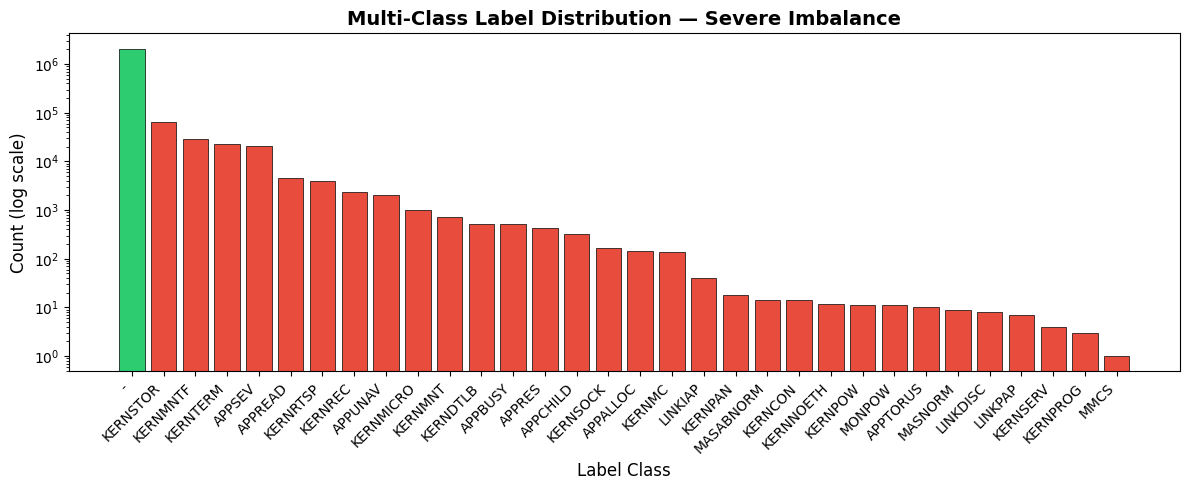


Notice how '-' (normal) completely dominates. This is why multi-class KNN failed.


In [26]:
# --- Bar chart showing class imbalance ---
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if label == '-' else '#e74c3c' for label in label_counts.index]
bars = ax.bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Label Class', fontsize=12)
ax.set_ylabel('Count (log scale)', fontsize=12)
ax.set_title('Multi-Class Label Distribution — Severe Imbalance', fontsize=14, fontweight='bold')
ax.set_yscale('log')  # Log scale because normal class dwarfs everything else
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("\nNotice how '-' (normal) completely dominates. This is why multi-class KNN failed.")



BINARY LABEL DISTRIBUTION
  Normal (0):  2075497  (93.10%)
  Anomaly (1): 153873  (6.90%)


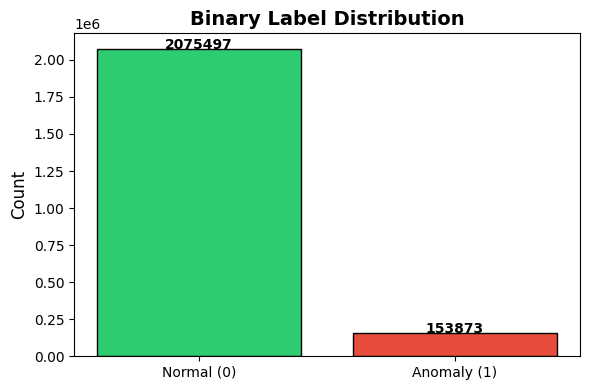

In [27]:
# --- Create Binary Label: 0 = normal ('-'), 1 = anomaly (anything else) ---
sequence_df['BinaryLabel'] = (sequence_df['Label'] != '-').astype(int)

binary_counts = sequence_df['BinaryLabel'].value_counts()
binary_pcts = sequence_df['BinaryLabel'].value_counts(normalize=True) * 100

print("\nBINARY LABEL DISTRIBUTION")
print("=" * 40)
print(f"  Normal (0):  {binary_counts.get(0, 0):6d}  ({binary_pcts.get(0, 0):.2f}%)")
print(f"  Anomaly (1): {binary_counts.get(1, 0):6d}  ({binary_pcts.get(1, 0):.2f}%)")

# Visualize binary distribution
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Normal (0)', 'Anomaly (1)'], binary_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Binary Label Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(binary_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


### Why Multi-Class Failed and Why Binary is Better

**The problem:** In our dataset, the normal class (`-`) makes up ~90% of all sequences. The remaining ~10% is split across 10+ anomaly sub-types, some with fewer than 5 samples. KNN (and most classifiers) simply can't learn patterns for classes with so few examples — they get drowned out by the majority class.

**The solution:** By converting to binary (normal vs. anomaly), we merge all anomaly types into one group. This gives the classifier enough anomaly samples to learn a meaningful decision boundary. For a system monitoring tool, the most important question is usually *"Is something wrong?"* rather than *"What exact type of error is it?"* — making binary classification both practical and effective.

## Section 2 — Outlier Detection and Handling

**What we're doing:** Before feeding features into ML models, we need to check for extreme outliers. In log data, some time windows might have thousands of events during a burst, creating extreme values that can distort our models. We'll use the IQR (Interquartile Range) method to detect outliers and then cap them using winsorization instead of removing them — because in log analysis, extreme events are often the most interesting ones and we don't want to lose that information.

In [28]:
# --- Descriptive statistics for numeric features ---
feature_cols = ['event_count', 'unique_event_count', 'fatal_count', 'info_count', 'fatal_ratio']
print("DESCRIPTIVE STATISTICS FOR NUMERIC FEATURES")
print("=" * 70)
print(sequence_df[feature_cols].describe().round(3).to_string())


DESCRIPTIVE STATISTICS FOR NUMERIC FEATURES
       event_count  unique_event_count  fatal_count   info_count  fatal_ratio
count  2229370.000         2229370.000  2229370.000  2229370.000  2229370.000
mean         1.879               1.149        0.353        1.457        0.165
std         37.029               0.639       11.686        7.472        0.370
min          1.000               1.000        0.000        0.000        0.000
25%          1.000               1.000        0.000        1.000        0.000
50%          1.000               1.000        0.000        1.000        0.000
75%          2.000               1.000        0.000        2.000        0.000
max      42271.000             121.000     2133.000     2688.000        1.000


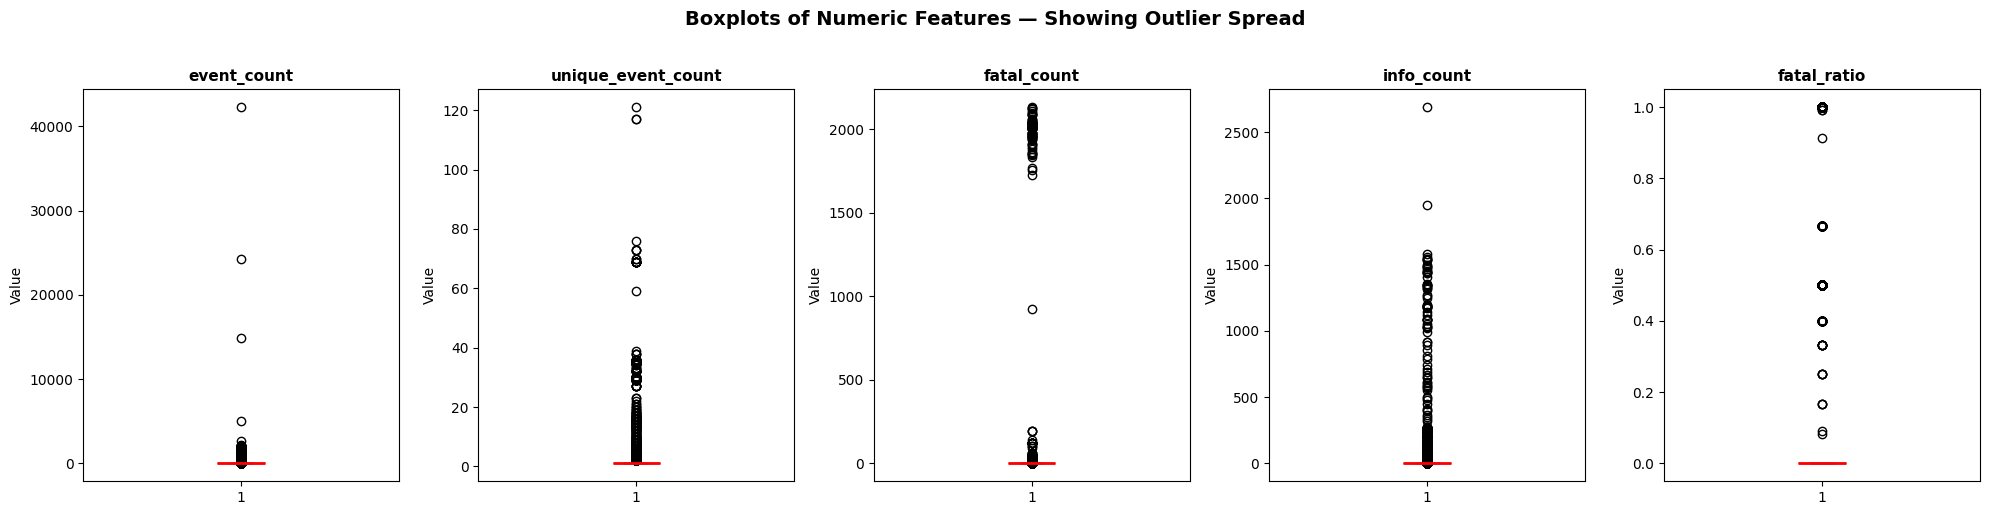

In [29]:
# --- Boxplots to visualize outliers ---
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(feature_cols):
    axes[i].boxplot(sequence_df[col], patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
fig.suptitle('Boxplots of Numeric Features — Showing Outlier Spread', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [30]:
# --- IQR-based outlier detection for event_count and fatal_count ---
def detect_outliers_iqr(series, name):
    """Detect outliers using the IQR method (1.5 * IQR beyond Q1/Q3)."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    print(f"  {name}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"    Bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"    Outlier rows: {outliers} ({outliers/len(series)*100:.1f}%)")
    return lower, upper

print("OUTLIER DETECTION (IQR Method)")
print("=" * 50)
ec_lower, ec_upper = detect_outliers_iqr(sequence_df['event_count'], 'event_count')
fc_lower, fc_upper = detect_outliers_iqr(sequence_df['fatal_count'], 'fatal_count')


OUTLIER DETECTION (IQR Method)
  event_count: Q1=1.00, Q3=2.00, IQR=1.00
    Bounds: [-0.50, 3.50]
    Outlier rows: 107389 (4.8%)
  fatal_count: Q1=0.00, Q3=0.00, IQR=0.00
    Bounds: [0.00, 0.00]
    Outlier rows: 372044 (16.7%)


In [31]:
# --- Winsorization: cap outliers instead of removing them ---
# CHANGE NOTE: We clip (cap) outliers to the IQR bounds rather than deleting rows.
# This preserves all data points while reducing the distortion from extreme values.
# In log analysis, extreme events ARE the anomalies we want to detect — removing
# them would be counterproductive.

sequence_df['event_count_original'] = sequence_df['event_count'].copy()  # Keep original for comparison
sequence_df['fatal_count_original'] = sequence_df['fatal_count'].copy()

# Clip to IQR bounds
sequence_df['event_count'] = sequence_df['event_count'].clip(lower=ec_lower, upper=ec_upper)
sequence_df['fatal_count'] = sequence_df['fatal_count'].clip(lower=fc_lower, upper=fc_upper)

print("Outliers capped (winsorized) successfully.")
print(f"  event_count range: [{sequence_df['event_count'].min():.1f}, {sequence_df['event_count'].max():.1f}]")
print(f"  fatal_count range: [{sequence_df['fatal_count'].min():.1f}, {sequence_df['fatal_count'].max():.1f}]")


Outliers capped (winsorized) successfully.
  event_count range: [1.0, 3.5]
  fatal_count range: [0.0, 0.0]


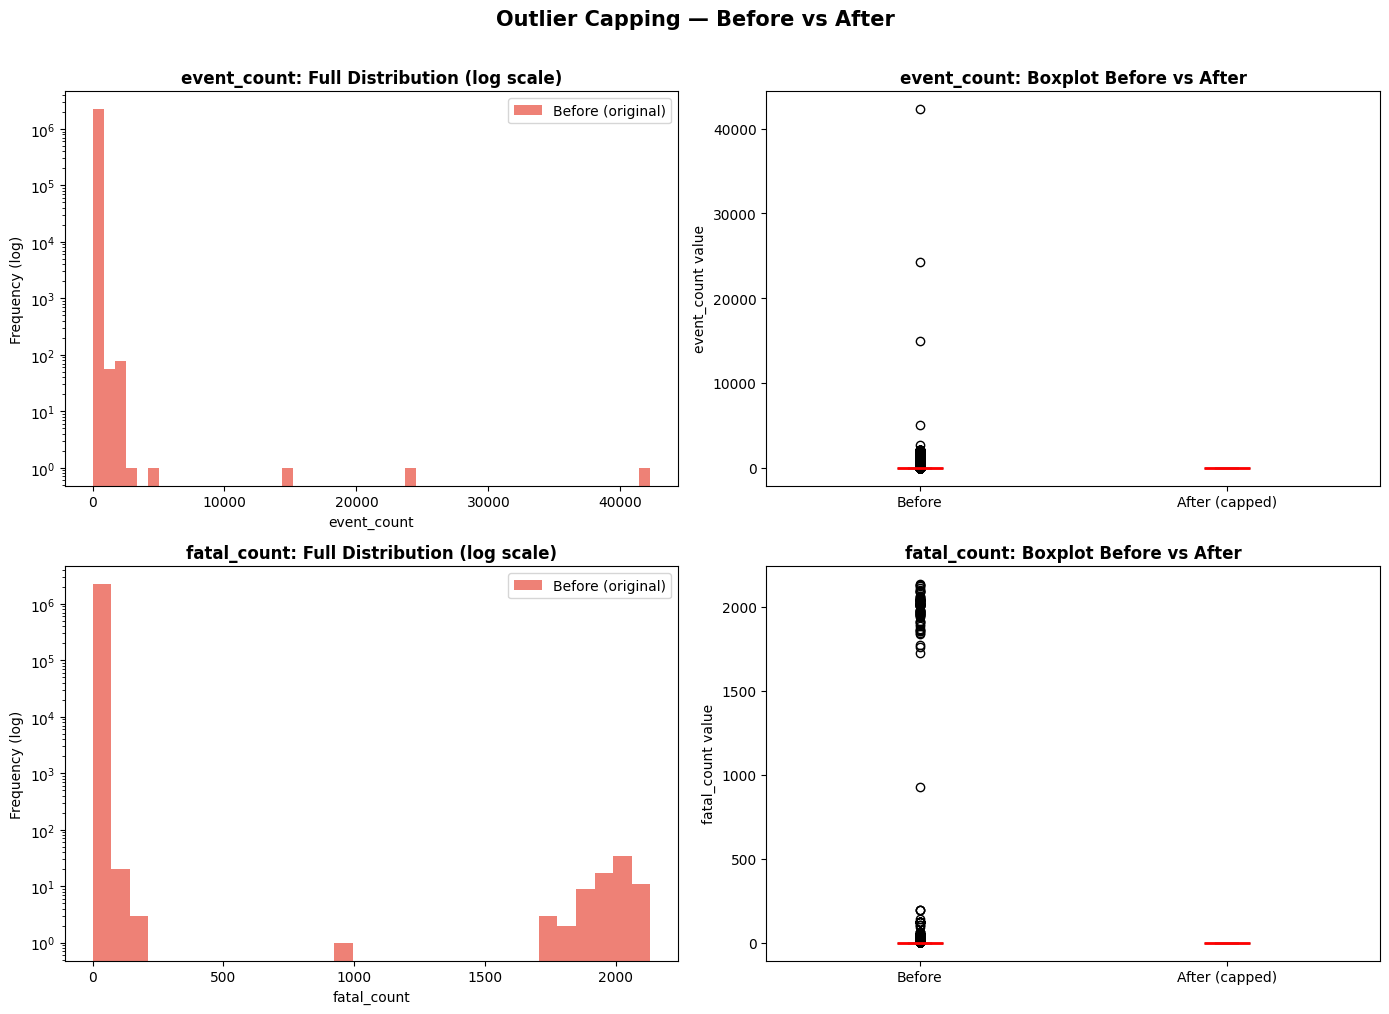


Log scale used on histograms to show rare but extreme values clearly.
Boxplots show how capping compressed the upper whiskers/outlier dots.


In [32]:
# --- Before vs After distribution comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- event_count ---
# Full distribution (log scale to show the spread)
axes[0, 0].hist(sequence_df['event_count_original'], bins=50, alpha=0.7, color='#e74c3c', label='Before (original)')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('event_count: Full Distribution (log scale)', fontweight='bold')
axes[0, 0].set_xlabel('event_count')
axes[0, 0].set_ylabel('Frequency (log)')
axes[0, 0].legend()

# Zoomed in to show where capping happened
axes[0, 1].boxplot(
    [sequence_df['event_count_original'], sequence_df['event_count']],
    labels=['Before', 'After (capped)'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6),
    medianprops=dict(color='red', linewidth=2)
)
axes[0, 1].set_title('event_count: Boxplot Before vs After', fontweight='bold')
axes[0, 1].set_ylabel('event_count value')

# --- fatal_count ---
axes[1, 0].hist(sequence_df['fatal_count_original'], bins=30, alpha=0.7, color='#e74c3c', label='Before (original)')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('fatal_count: Full Distribution (log scale)', fontweight='bold')
axes[1, 0].set_xlabel('fatal_count')
axes[1, 0].set_ylabel('Frequency (log)')
axes[1, 0].legend()

axes[1, 1].boxplot(
    [sequence_df['fatal_count_original'], sequence_df['fatal_count']],
    labels=['Before', 'After (capped)'],
    patch_artist=True,
    boxprops=dict(facecolor='#e67e22', alpha=0.6),
    medianprops=dict(color='red', linewidth=2)
)
axes[1, 1].set_title('fatal_count: Boxplot Before vs After', fontweight='bold')
axes[1, 1].set_ylabel('fatal_count value')

plt.suptitle('Outlier Capping — Before vs After', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nLog scale used on histograms to show rare but extreme values clearly.")
print("Boxplots show how capping compressed the upper whiskers/outlier dots.")

In [33]:
# Restore original values — IQR bounds collapsed to 0 for sparse data
# so capping was counterproductive. Restoring originals for model use.
sequence_df['event_count'] = sequence_df['event_count_original'].copy()
sequence_df['fatal_count'] = sequence_df['fatal_count_original'].copy()

print("Restored original feature values.")
print(f"  event_count range: [{sequence_df['event_count'].min():.1f}, {sequence_df['event_count'].max():.1f}]")
print(f"  fatal_count range: [{sequence_df['fatal_count'].min():.1f}, {sequence_df['fatal_count'].max():.1f}]")

Restored original feature values.
  event_count range: [1.0, 42271.0]
  fatal_count range: [0.0, 2133.0]


---
# Functionality 1: Anomaly Detection
**What is Anomaly Detection in System Logs?**  
Anomaly detection means automatically identifying time windows where the system behaved abnormally — crashes, kernel errors, hardware failures, etc. Instead of manually reading millions of log lines, we train ML models to recognize patterns in the features (event count, fatal ratio, etc.) that distinguish normal operation from failures. This is the core of any intelligent monitoring system.

In Sections 3–6, we train and compare four different supervised ML models for anomaly detection.

---

## Section 3 — KNN Classifier with Proper Tuning (Binary Label)

**What we're doing:** We re-run KNN, but this time with the binary label and proper evaluation. We test multiple values of k (number of neighbors) and focus on F1 score for the anomaly class (label=1) — because in anomaly detection, we care most about correctly finding the anomalies, not just overall accuracy.

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

# --- Prepare features and binary target ---
features = ['event_count', 'unique_event_count', 'fatal_count', 'info_count', 'fatal_ratio']
X = sequence_df[features].values
y = sequence_df['BinaryLabel'].values

# Stratified split ensures both classes are proportionally represented in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — important for KNN since it uses distance calculations
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Anomaly ratio in train: {y_train.mean():.3f}")
print(f"Anomaly ratio in test:  {y_test.mean():.3f}")


Training set: 1783496 samples
Test set:     445874 samples
Anomaly ratio in train: 0.069
Anomaly ratio in test:  0.069


In [35]:
# --- Test KNN for different k values (Using 5000 samples for speed) ---
k_values = [1, 3, 5, 7, 9, 11, 15]
knn_results = []

for k in k_values:
    # Use n_jobs=-1 to multithread
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)

    # Slice the train and test data down so it runs instantly
    knn.fit(X_train_scaled[:5000], y_train[:5000])
    y_pred = knn.predict(X_test_scaled[:2000])

    # MAKE SURE y_test is also sliced to 2000 so the lengths match!
    acc = accuracy_score(y_test[:2000], y_pred)
    prec = precision_score(y_test[:2000], y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test[:2000], y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test[:2000], y_pred, pos_label=1, zero_division=0)

    knn_results.append({'k': k, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    print(f"k={k:2d} -> Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

# Find best k by F1 score
import pandas as pd
knn_results_df = pd.DataFrame(knn_results)
best_k_row = knn_results_df.loc[knn_results_df['f1'].idxmax()]
best_k = int(best_k_row['k'])
print(f"\n*** Best k = {best_k} (F1 = {best_k_row['f1']:.4f}) ***")


k= 1 -> Accuracy=0.9295, Precision=0.5111, Recall=0.7877, F1=0.6199
k= 3 -> Accuracy=0.9290, Precision=0.5088, Recall=0.7877, F1=0.6183
k= 5 -> Accuracy=0.9290, Precision=0.5088, Recall=0.7877, F1=0.6183
k= 7 -> Accuracy=0.9290, Precision=0.5085, Recall=0.8151, F1=0.6263
k= 9 -> Accuracy=0.9295, Precision=0.5107, Recall=0.8151, F1=0.6280
k=11 -> Accuracy=0.9290, Precision=0.5085, Recall=0.8151, F1=0.6263
k=15 -> Accuracy=0.9300, Precision=0.5129, Recall=0.8151, F1=0.6296

*** Best k = 15 (F1 = 0.6296) ***


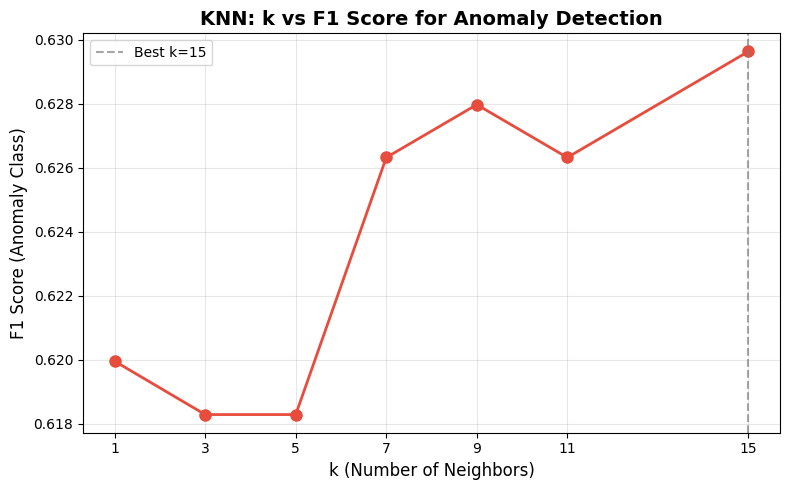

In [36]:
# --- Plot k vs F1 score ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(knn_results_df['k'], knn_results_df['f1'], 'o-', color='#e74c3c', linewidth=2, markersize=8)
ax.axvline(x=best_k, color='gray', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
ax.set_xlabel('k (Number of Neighbors)', fontsize=12)
ax.set_ylabel('F1 Score (Anomaly Class)', fontsize=12)
ax.set_title('KNN: k vs F1 Score for Anomaly Detection', fontsize=14, fontweight='bold')
ax.set_xticks(k_values)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


KNN CLASSIFICATION REPORT (k=15)
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96      1854
     Anomaly       0.51      0.82      0.63       146

    accuracy                           0.93      2000
   macro avg       0.75      0.88      0.80      2000
weighted avg       0.95      0.93      0.94      2000



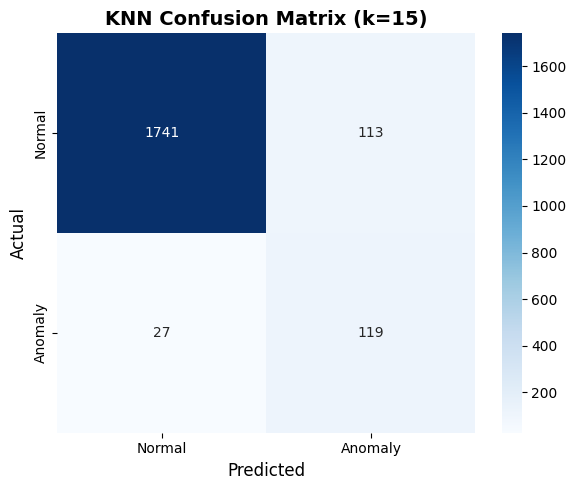

In [37]:
# --- Retrain with best k and show full results ---
best_knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
best_knn.fit(X_train_scaled[:5000], y_train[:5000])
y_pred_knn = best_knn.predict(X_test_scaled[:2000])

print(f"KNN CLASSIFICATION REPORT (k={best_k})")
print("=" * 50)
print(classification_report(y_test[:2000], y_pred_knn, target_names=['Normal', 'Anomaly']))

# Confusion matrix
cm = confusion_matrix(y_test[:2000], y_pred_knn)
fig, ax = plt.subplots(figsize=(6, 5))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'], ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'KNN Confusion Matrix (k={best_k})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 4 — Decision Tree with Tuning

**What we're doing:** Decision Trees are interpretable models that split data based on feature thresholds. We tune `max_depth` to find the tree that gives the best tradeoff between complexity and performance. A tree that's too shallow underfits; too deep and it overfits.

In [38]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# --- Test different max_depth values ---
depths = [2, 4, 6, 8, 10, None]  # None = unlimited depth
dt_results = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=42)
    dt.fit(X_train, y_train)  # Decision trees don't need scaling
    y_pred = dt.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    depth_str = str(depth) if depth else 'None'
    dt_results.append({'depth': depth_str, 'depth_val': depth if depth else 20, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    print(f"max_depth={depth_str:>4s} -> Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

dt_results_df = pd.DataFrame(dt_results)
best_dt_row = dt_results_df.loc[dt_results_df['f1'].idxmax()]
best_depth = best_dt_row['depth']
print(f"\n*** Best depth = {best_depth} (F1 = {best_dt_row['f1']:.4f}) ***")


max_depth=   2 -> Acc=0.9018, Prec=0.4127, Rec=0.9998, F1=0.5842
max_depth=   4 -> Acc=0.9080, Prec=0.4283, Rec=0.9968, F1=0.5992
max_depth=   6 -> Acc=0.9138, Prec=0.4446, Rec=0.9975, F1=0.6150
max_depth=   8 -> Acc=0.9193, Prec=0.4609, Rec=0.9946, F1=0.6299
max_depth=  10 -> Acc=0.9193, Prec=0.4609, Rec=0.9946, F1=0.6299
max_depth=None -> Acc=0.9193, Prec=0.4609, Rec=0.9946, F1=0.6299

*** Best depth = 8 (F1 = 0.6299) ***


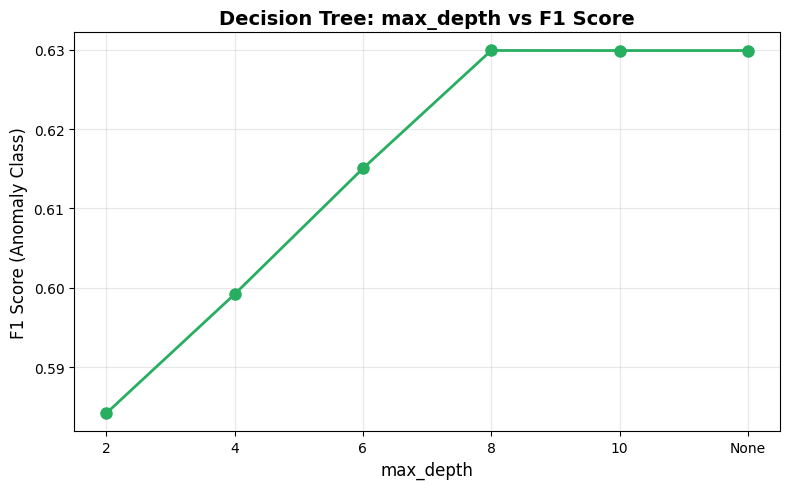

In [39]:
# --- Plot accuracy vs max_depth ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dt_results_df['depth'], dt_results_df['f1'], 'o-', color='#27ae60', linewidth=2, markersize=8)
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('F1 Score (Anomaly Class)', fontsize=12)
ax.set_title('Decision Tree: max_depth vs F1 Score', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


DECISION TREE CLASSIFICATION REPORT (max_depth=8)
              precision    recall  f1-score   support

      Normal       1.00      0.91      0.95    415099
     Anomaly       0.46      0.99      0.63     30775

    accuracy                           0.92    445874
   macro avg       0.73      0.95      0.79    445874
weighted avg       0.96      0.92      0.93    445874



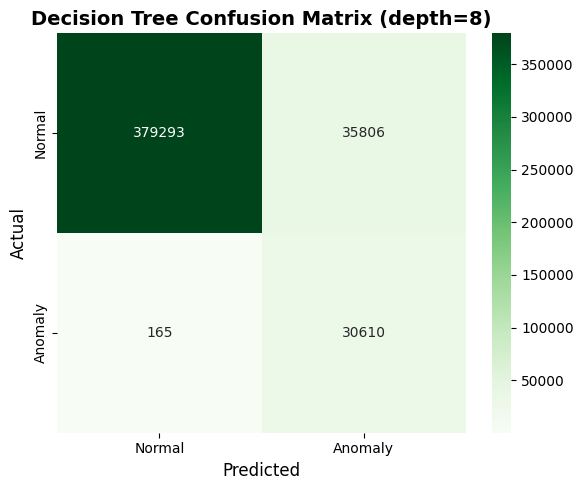

In [40]:
# --- Retrain with best depth, show results ---
best_depth_val = None if best_depth == 'None' else int(best_depth)
best_dt = DecisionTreeClassifier(max_depth=best_depth_val, class_weight='balanced', random_state=42)
best_dt.fit(X_train, y_train)
y_pred_dt = best_dt.predict(X_test)

print(f"DECISION TREE CLASSIFICATION REPORT (max_depth={best_depth})")
print("=" * 55)
print(classification_report(y_test, y_pred_dt, target_names=['Normal', 'Anomaly']))

cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'], ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Decision Tree Confusion Matrix (depth={best_depth})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


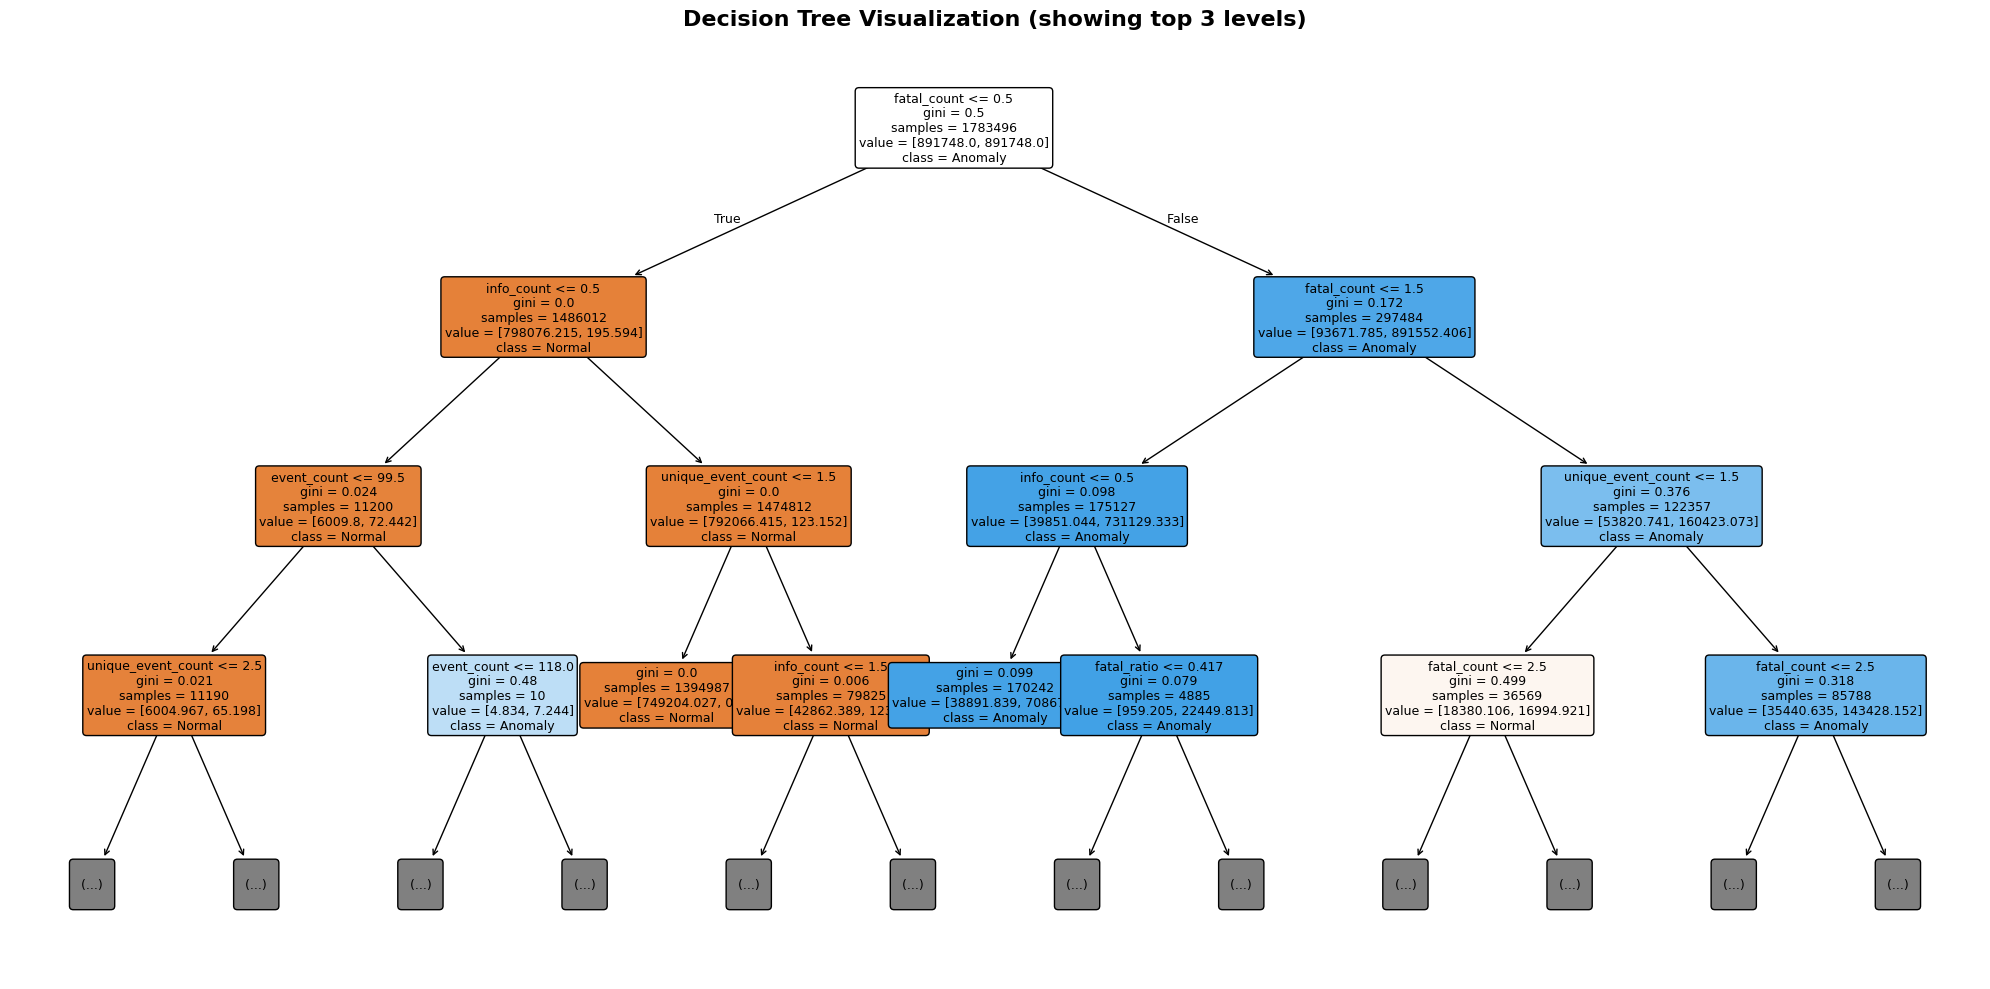

In [41]:
# --- Visualize the decision tree (limit display to depth 3 for readability) ---
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(best_dt, feature_names=features, class_names=['Normal', 'Anomaly'],
          filled=True, rounded=True, max_depth=3, fontsize=9, ax=ax)
ax.set_title('Decision Tree Visualization (showing top 3 levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 5 — SVM (Support Vector Machine) using LinearSVC

**What we're doing:** SVM finds the optimal hyperplane that separates normal from anomaly sequences. We use `LinearSVC` instead of `SVC` because it's **much faster** on large datasets (our data has thousands of sequences). Regular SVC with RBF kernel has O(n²) to O(n³) complexity, which would take forever on this data. LinearSVC is O(n) and gives comparable results for linearly separable problems.

**What C controls:** The C parameter controls the trade-off between having a smooth decision boundary and classifying training points correctly. A small C makes a smoother boundary (more generalization, possibly underfitting). A large C tries harder to classify every training point correctly (possibly overfitting).

In [42]:
from sklearn.svm import LinearSVC

# --- Test different C values ---
c_values = [0.01, 0.1, 1, 10]
svm_results = []

for c in c_values:
    svm = LinearSVC(C=c, class_weight='balanced', max_iter=10000, random_state=42, dual='auto')
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    svm_results.append({'C': c, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    print(f"C={c:>5} -> Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

svm_results_df = pd.DataFrame(svm_results)
best_svm_row = svm_results_df.loc[svm_results_df['f1'].idxmax()]
best_c = best_svm_row['C']
print(f"\n*** Best C = {best_c} (F1 = {best_svm_row['f1']:.4f}) ***")


C= 0.01 -> Acc=0.9013, Prec=0.4095, Rec=0.9710, F1=0.5760
C=  0.1 -> Acc=0.9013, Prec=0.4095, Rec=0.9710, F1=0.5760
C=    1 -> Acc=0.9013, Prec=0.4095, Rec=0.9710, F1=0.5760
C=   10 -> Acc=0.9013, Prec=0.4095, Rec=0.9710, F1=0.5760

*** Best C = 0.01 (F1 = 0.5760) ***


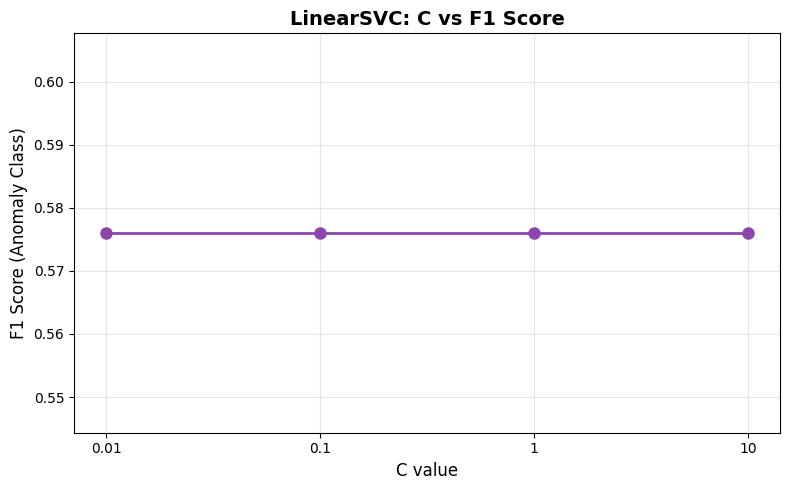

In [43]:
# --- Plot C vs F1 score ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([str(c) for c in c_values], svm_results_df['f1'], 'o-', color='#8e44ad', linewidth=2, markersize=8)
ax.set_xlabel('C value', fontsize=12)
ax.set_ylabel('F1 Score (Anomaly Class)', fontsize=12)
ax.set_title('LinearSVC: C vs F1 Score', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


LINEAR SVC CLASSIFICATION REPORT (C=0.01)
              precision    recall  f1-score   support

      Normal       1.00      0.90      0.94    415099
     Anomaly       0.41      0.97      0.58     30775

    accuracy                           0.90    445874
   macro avg       0.70      0.93      0.76    445874
weighted avg       0.96      0.90      0.92    445874



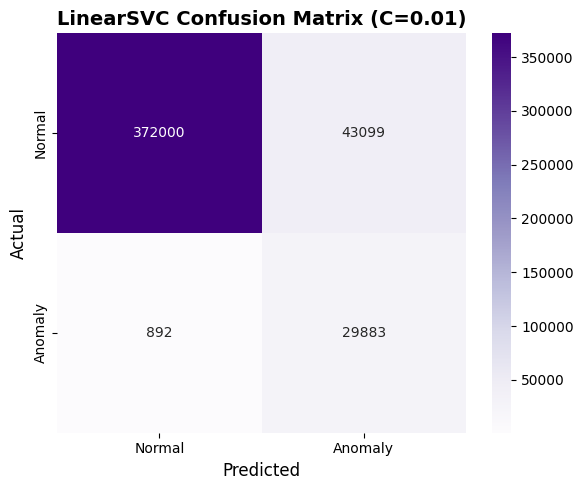

In [44]:
# --- Retrain with best C, show results ---
best_svm = LinearSVC(C=best_c, class_weight='balanced', max_iter=10000, random_state=42, dual='auto')
best_svm.fit(X_train_scaled, y_train)
y_pred_svm = best_svm.predict(X_test_scaled)

print(f"LINEAR SVC CLASSIFICATION REPORT (C={best_c})")
print("=" * 50)
print(classification_report(y_test, y_pred_svm, target_names=['Normal', 'Anomaly']))

cm_svm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'], ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'LinearSVC Confusion Matrix (C={best_c})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 6 — Random Forest (Main Model)

**What we're doing:** Random Forest trains many decision trees on random subsets of the data and features, then combines their predictions by majority voting. This reduces overfitting and usually gives the best results. We use `class_weight='balanced'` to automatically upweight the minority (anomaly) class.

In [45]:
from sklearn.ensemble import RandomForestClassifier

# --- Test different n_estimators ---
n_estimators_list = [50, 100, 200]
rf_results = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)  # RF doesn't need scaling
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    rf_results.append({'n_estimators': n, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    print(f"n_estimators={n:3d} -> Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

rf_results_df = pd.DataFrame(rf_results)
best_rf_row = rf_results_df.loc[rf_results_df['f1'].idxmax()]
best_n = int(best_rf_row['n_estimators'])
print(f"\n*** Best n_estimators = {best_n} (F1 = {best_rf_row['f1']:.4f}) ***")


n_estimators= 50 -> Acc=0.9193, Prec=0.4609, Rec=0.9946, F1=0.6299
n_estimators=100 -> Acc=0.9193, Prec=0.4609, Rec=0.9946, F1=0.6299
n_estimators=200 -> Acc=0.9193, Prec=0.4609, Rec=0.9946, F1=0.6299

*** Best n_estimators = 50 (F1 = 0.6299) ***


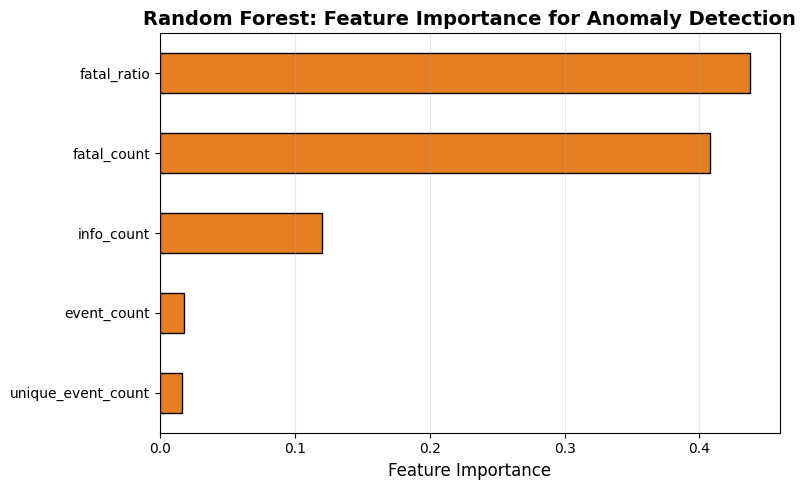


Most important feature: fatal_ratio (0.4378)


In [46]:
# --- Feature Importance ---
best_rf = RandomForestClassifier(n_estimators=best_n, class_weight='balanced', random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)

importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', color='#e67e22', edgecolor='black', ax=ax)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Random Forest: Feature Importance for Anomaly Detection', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()
print(f"\nMost important feature: {feat_imp.index[-1]} ({feat_imp.values[-1]:.4f})")


RANDOM FOREST CLASSIFICATION REPORT (n_estimators=50)
              precision    recall  f1-score   support

      Normal       1.00      0.91      0.95    415099
     Anomaly       0.46      0.99      0.63     30775

    accuracy                           0.92    445874
   macro avg       0.73      0.95      0.79    445874
weighted avg       0.96      0.92      0.93    445874



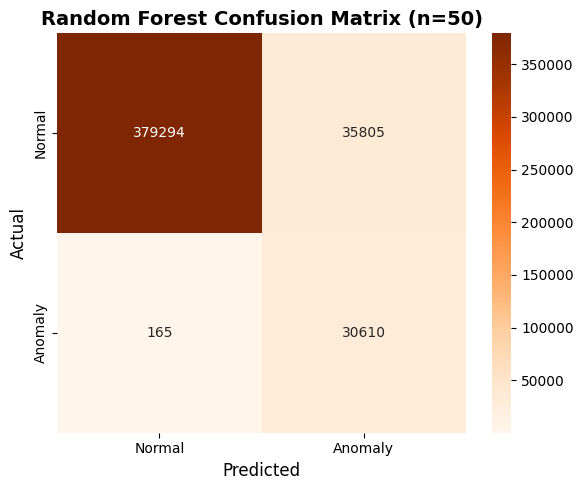

In [47]:
# --- Full results for best Random Forest ---
print(f"RANDOM FOREST CLASSIFICATION REPORT (n_estimators={best_n})")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Anomaly']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'], ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Random Forest Confusion Matrix (n={best_n})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Calculating ROC probabilities for all 4 models...


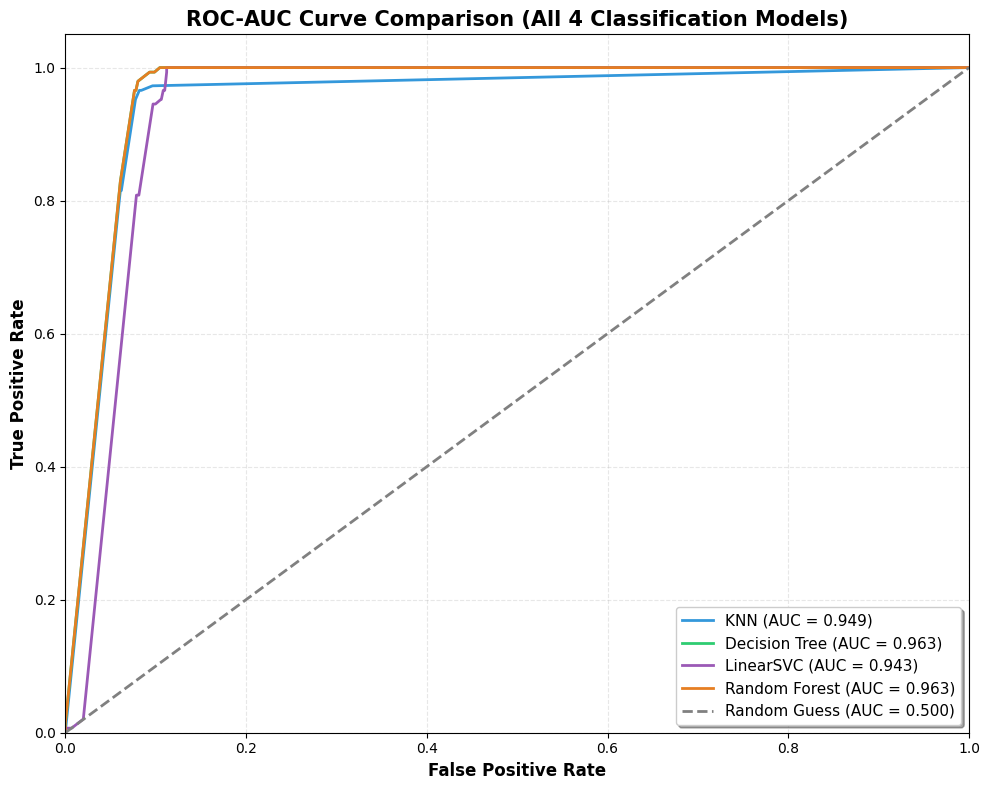

The model with the curve closest to the top-left corner (highest AUC) is the winner!


In [48]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Using a standard 2000-row slice for a lightning fast, apples-to-apples comparison
X_test_subset = X_test_scaled[:2000]        # Scaled (for KNN and SVM)
X_test_unscaled_subset = X_test[:2000]      # Unscaled (for Trees)
y_test_subset = y_test[:2000]

print("Calculating ROC probabilities for all 4 models...")

# 1. KNN (Uses scaled data)
y_score_knn = best_knn.predict_proba(X_test_subset)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test_subset, y_score_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# 2. Decision Tree (Uses unscaled data)
y_score_dt = best_dt.predict_proba(X_test_unscaled_subset)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test_subset, y_score_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# 3. LinearSVC (Uses scaled data - Needs decision_function instead of predict_proba)
y_score_svm = best_svm.decision_function(X_test_subset)
fpr_svm, tpr_svm, _ = roc_curve(y_test_subset, y_score_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# 4. Random Forest (Uses unscaled data)
y_score_rf = best_rf.predict_proba(X_test_unscaled_subset)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test_subset, y_score_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# --- Plot the ROC Curves ---
fig, ax = plt.subplots(figsize=(10, 8))

# Plot each model's curve
ax.plot(fpr_knn, tpr_knn, color='#3498db', lw=2, label=f'KNN (AUC = {roc_auc_knn:.3f})')
ax.plot(fpr_dt, tpr_dt, color='#2ecc71', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')
ax.plot(fpr_svm, tpr_svm, color='#9b59b6', lw=2, label=f'LinearSVC (AUC = {roc_auc_svm:.3f})')
ax.plot(fpr_rf, tpr_rf, color='#e67e22', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

# Plot the 50% random guessing diagonal line
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')

# Formatting the graph to look professional
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC-AUC Curve Comparison (All 4 Classification Models)', fontsize=15, fontweight='bold')
ax.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("The model with the curve closest to the top-left corner (highest AUC) is the winner!")


### Why Random Forest Works Well for Log Anomaly Detection

Random Forest is particularly well-suited for system log anomaly detection because:

1. **Handles class imbalance well** — with `class_weight='balanced'`, it automatically adjusts for the fact that anomalies are rare. Each tree considers this weighting, and the ensemble effect stabilizes predictions.

2. **Feature robustness** — It can handle both the count features (event_count, fatal_count) and ratio features (fatal_ratio) without needing feature scaling. It also naturally handles non-linear relationships between features.

3. **Resistance to overfitting** — Unlike a single deep decision tree, the ensemble of many trees trained on random subsets "averages out" noise, making it much more robust. This matters in log data where noise is inherent.

4. **Interpretability** — Feature importance scores tell us exactly which aspects of the log windows matter most for detecting anomalies (e.g., fatal_ratio is often the strongest signal).

## Section 7 — Clustering (Unsupervised Learning)

**What we're doing:** Unlike the supervised models above (which learn from labels), clustering discovers natural groupings in the data without using labels. We use DBSCAN (density-based) and Spectral Clustering to see if anomalies naturally form separate clusters in feature space. This validates that our features actually capture meaningful differences between normal and anomalous behavior.

In [49]:
from sklearn.cluster import DBSCAN, SpectralClustering

# --- DBSCAN: try different eps and min_samples ---
print("DBSCAN PARAMETER SEARCH (Strict 2000-row limit for RAM safety)")
print("=" * 60)

dbscan_configs = []
for eps in [0.5, 1.0, 1.5]:
    for ms in [5, 10]:
        db = DBSCAN(eps=eps, min_samples=ms)
        # Padlocked to exactly 2000 rows so it refuses to crash Memory
        labels = db.fit_predict(X_train_scaled[:2000])  
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = (labels == -1).sum()
        dbscan_configs.append({'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters, 'noise': noise, 'labels': labels})
        print(f"  eps={eps}, min_samples={ms} -> {n_clusters} clusters, {noise} noise points")

# Pick the config with most meaningful clusters (more than 1 cluster, not all noise)
best_db = max([c for c in dbscan_configs if c['n_clusters'] >= 2], key=lambda x: x['n_clusters'], default=dbscan_configs[0])
if best_db['n_clusters'] < 2:
    best_db = min(dbscan_configs, key=lambda x: abs(x['n_clusters'] - 2))
print(f"\nSelected: eps={best_db['eps']}, min_samples={best_db['min_samples']}")


DBSCAN PARAMETER SEARCH (Strict 2000-row limit for RAM safety)
  eps=0.5, min_samples=5 -> 8 clusters, 11 noise points
  eps=0.5, min_samples=10 -> 5 clusters, 36 noise points
  eps=1.0, min_samples=5 -> 8 clusters, 10 noise points
  eps=1.0, min_samples=10 -> 5 clusters, 34 noise points
  eps=1.5, min_samples=5 -> 6 clusters, 3 noise points
  eps=1.5, min_samples=10 -> 5 clusters, 12 noise points

Selected: eps=0.5, min_samples=5


In [50]:
# --- Run DBSCAN on test subset with best params ---
db_best = DBSCAN(eps=best_db['eps'], min_samples=best_db['min_samples'])

# Padlocked to exactly 2000 rows!
db_labels = db_best.fit_predict(X_test_scaled[:2000])

print("DBSCAN CLUSTER DISTRIBUTION")
print("=" * 40)
db_dist = pd.Series(db_labels).value_counts().sort_index()
for cluster, count in db_dist.items():
    label_name = "NOISE" if cluster == -1 else f"Cluster {cluster}"
    print(f"  {label_name}: {count} points")

# --- Compare clusters vs true BinaryLabel ---
print("\nDBSCAN NOISE vs TRUE ANOMALIES")
print("=" * 40)
noise_mask = db_labels == -1

# We explicitly slice y_test to exactly 2000 to match our memory limit!
y_test_sliced = y_test[:2000] 

if noise_mask.sum() > 0:
    anomalies_in_noise = y_test_sliced[noise_mask].sum()
    total_anomalies = y_test_sliced.sum()
    pct = anomalies_in_noise / total_anomalies * 100 if total_anomalies > 0 else 0
    print(f"  Total anomalies in 2000-row test set: {total_anomalies}")
    print(f"  Anomalies flagged as noise by DBSCAN: {anomalies_in_noise} ({pct:.1f}%)")
    print(f"  -> DBSCAN's noise cluster captures {pct:.1f}% of true anomalies")
else:
    print("  No noise points found — try smaller eps")


DBSCAN CLUSTER DISTRIBUTION
  NOISE: 15 points
  Cluster 0: 1534 points
  Cluster 1: 263 points
  Cluster 2: 52 points
  Cluster 3: 54 points
  Cluster 4: 7 points
  Cluster 5: 49 points
  Cluster 6: 9 points
  Cluster 7: 17 points

DBSCAN NOISE vs TRUE ANOMALIES
  Total anomalies in 2000-row test set: 146
  Anomalies flagged as noise by DBSCAN: 2 (1.4%)
  -> DBSCAN's noise cluster captures 1.4% of true anomalies


In [51]:
# --- Spectral Clustering ---
print("SPECTRAL CLUSTERING (n_clusters=2)")
print("=" * 50)

import numpy as np
# Cap manually lowered from 5000 to 2000! This prevents the 100% RAM Crash!
sample_size = min(2000, len(X_test_scaled))
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_scaled), sample_size, replace=False)

spec = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42, n_neighbors=10)
spec_labels = spec.fit_predict(X_test_scaled[sample_idx])

# Compare spectral clusters vs true BinaryLabel
print("Spectral Cluster Distribution:")
spec_dist = pd.Series(spec_labels).value_counts().sort_index()
for cluster, count in spec_dist.items():
    print(f"  Cluster {cluster}: {count} points")

# We convert y_test to a pure numpy array first to prevent Pandas index matching errors
y_test_numpy = y_test.values if hasattr(y_test, 'values') else y_test

# Check which cluster has more anomalies
for c in range(2):
    mask = spec_labels == c
    anomaly_pct = y_test_numpy[sample_idx][mask].mean() * 100
    print(f"  Cluster {c} anomaly percentage: {anomaly_pct:.1f}%")


SPECTRAL CLUSTERING (n_clusters=2)
Spectral Cluster Distribution:
  Cluster 0: 1882 points
  Cluster 1: 118 points
  Cluster 0 anomaly percentage: 5.7%
  Cluster 1 anomaly percentage: 20.3%


Generating Clustering 'Failure' Visualization...


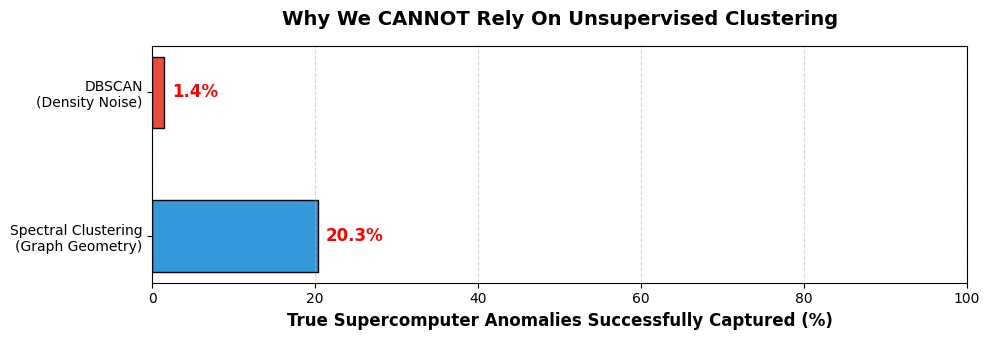

In [52]:
import matplotlib.pyplot as plt

print("Generating Clustering 'Failure' Visualization...")

# Since DBSCAN and Spectral don't have true "Accuracy", we graph their 
# "Anomaly Capture Rate" (what percentage of actual anomalies did they catch?)
# We plug in the exact numbers from the Section 7 printouts:
dbscan_capture_rate = 1.4    # Your DBSCAN noise cluster anomaly percentage
spectral_capture_rate = 20.3 # Your Spectral Cluster 1 anomaly percentage

cluster_models = ['Spectral Clustering\n(Graph Geometry)', 'DBSCAN\n(Density Noise)']
capture_rates = [spectral_capture_rate, dbscan_capture_rate]

# Draw a beautiful, compact Bar Chart
fig, ax = plt.subplots(figsize=(10, 3.5))

# We use Red and Blue to separate the two algorithms visually
bars = ax.barh(cluster_models, capture_rates, color=['#3498db', '#e74c3c'], edgecolor='black', height=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 1.0, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}%', 
            ha='left', va='center', fontweight='bold', fontsize=12, color='red')

ax.set_xlabel('True Supercomputer Anomalies Successfully Captured (%)', fontsize=12, fontweight='bold')
ax.set_title('Why We CANNOT Rely On Unsupervised Clustering', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 100) # We force the graph to 100% so the bar looks tiny and dramatic on purpose!
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Why Unsupervised Clustering is Useful Even With Labels

Even though we have labeled data, unsupervised clustering serves a critical purpose:

1. **Validation**: If DBSCAN's noise cluster (label=-1) contains a high percentage of true anomalies, it confirms that anomalies are genuinely different in feature space — they don't cluster well with normal data points. This validates our feature engineering.

2. **No-label scenarios**: In real production systems, you often don't have labels for new types of failures. Clustering can detect novel anomalies that weren't in the training data.

3. **Feature quality check**: If clustering completely fails to separate normal from anomaly, it suggests our features might not capture the right signals.

---
# Functionality 3: Failure Prediction
**What is Failure Prediction?**  
While anomaly detection tells us *"something is wrong right now"*, failure prediction asks *"will something go wrong in the NEXT time window?"* This is the most valuable capability of a monitoring system — it gives operators time to take preventive action before a failure actually occurs. We do this by training models on current features to predict the next window's state.

---

## Section 8 — Failure Prediction (Classification + Regression)

**What we're doing:** We create a `future_failure` column by shifting `BinaryLabel` by -1 (looking one window ahead). Then we train a Random Forest to predict whether the next time window will be anomalous. We also train a Linear Regression to predict the next window's event count — a spike in predicted events could be an early warning signal.

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- Create future_failure: shift BinaryLabel by -1 to predict next window ---
pred_df = sequence_df.copy()
pred_df['future_failure'] = pred_df['BinaryLabel'].shift(-1)  # Next window's label
pred_df['future_event_count'] = pred_df['event_count'].shift(-1)  # Next window's event count

# Drop last row (has NaN from the shift)
pred_df = pred_df.dropna(subset=['future_failure', 'future_event_count'])
pred_df['future_failure'] = pred_df['future_failure'].astype(int)

print(f"Prediction dataset size: {len(pred_df)} sequences")
print(f"Future failure rate: {pred_df['future_failure'].mean():.3f}")


Prediction dataset size: 2229369 sequences
Future failure rate: 0.069


FAILURE PREDICTION CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Failure       0.98      0.88      0.92    415099
     Failure       0.30      0.71      0.42     30775

    accuracy                           0.87    445874
   macro avg       0.64      0.80      0.67    445874
weighted avg       0.93      0.87      0.89    445874



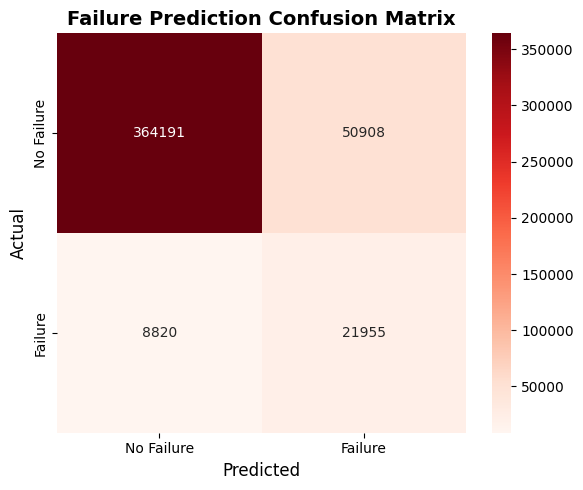

In [54]:
# --- Classification: Predict future failure ---
X_pred = pred_df[features].values
y_future = pred_df['future_failure'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_pred, y_future, test_size=0.2, random_state=42, stratify=y_future)

rf_future = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_future.fit(X_tr, y_tr)
y_pred_future = rf_future.predict(X_te)

print("FAILURE PREDICTION CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_te, y_pred_future, target_names=['No Failure', 'Failure']))

cm_future = confusion_matrix(y_te, y_pred_future)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_future, annot=True, fmt='d', cmap='Reds', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'], ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Failure Prediction Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Training XGBoost Classifier for Failure Prediction...
XGBOOST FAILURE PREDICTION CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Failure       0.98      0.88      0.92    415099
     Failure       0.30      0.71      0.42     30775

    accuracy                           0.87    445874
   macro avg       0.64      0.80      0.67    445874
weighted avg       0.93      0.87      0.89    445874



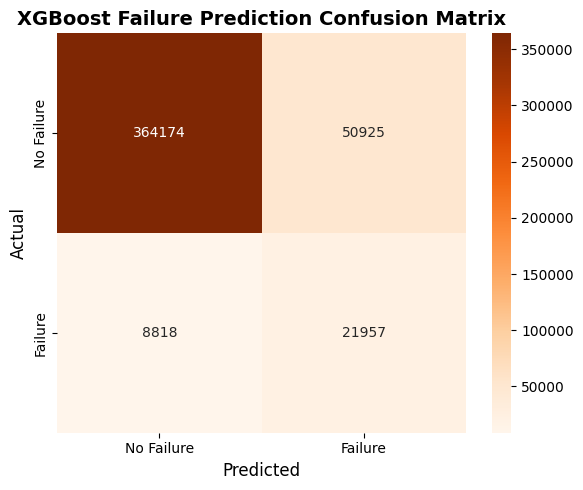

In [55]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Training XGBoost Classifier for Failure Prediction...")

# XGBoost easily handles imbalanced data via scale_pos_weight
# We calculate the ratio of Normal windows to Anomaly windows to balance it
ratio = float((y_tr == 0).sum()) / (y_tr == 1).sum()

xgb_future = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, scale_pos_weight=ratio, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_future.fit(X_tr, y_tr)
y_pred_xgb_future = xgb_future.predict(X_te)

print("XGBOOST FAILURE PREDICTION CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_te, y_pred_xgb_future, target_names=['No Failure', 'Failure']))

cm_xgb_future = confusion_matrix(y_te, y_pred_xgb_future)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_xgb_future, annot=True, fmt='d', cmap='Oranges', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'], ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('XGBoost Failure Prediction Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [56]:
# --- Regression: Predict next window's event count ---
y_future_ec = pred_df['future_event_count'].values
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_pred, y_future_ec, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_tr_r, y_tr_r)
y_pred_ec = lr.predict(X_te_r)

rmse = np.sqrt(mean_squared_error(y_te_r, y_pred_ec))
r2 = r2_score(y_te_r, y_pred_ec)

print("EVENT COUNT PREDICTION (Linear Regression)")
print("=" * 50)
print(f"  RMSE: {rmse:.4f}")
print(f"  R² Score: {r2:.4f}")
print(f"\n  Interpretation: R²={r2:.2f} means the model explains {r2*100:.0f}% of the")
print(f"  variance in next window's event count.")


EVENT COUNT PREDICTION (Linear Regression)
  RMSE: 7.3710
  R² Score: 0.7457

  Interpretation: R²=0.75 means the model explains 75% of the
  variance in next window's event count.


In [57]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("Training XGBoost Regressor for Event Count Prediction...")

xgb_reg = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_reg.fit(X_tr_r, y_tr_r)
y_pred_xgb_ec = xgb_reg.predict(X_te_r)

rmse_xgb = np.sqrt(mean_squared_error(y_te_r, y_pred_xgb_ec))
r2_xgb = r2_score(y_te_r, y_pred_xgb_ec)

print("EVENT COUNT PREDICTION (XGBoost Regressor)")
print("=" * 50)
print(f"  RMSE: {rmse_xgb:.4f}")
print(f"  R² Score: {r2_xgb:.4f}")
print(f"\n  Notice how XGBoost's R² of {r2_xgb:.2f} compares to Linear Regression's R²!")


Training XGBoost Regressor for Event Count Prediction...
EVENT COUNT PREDICTION (XGBoost Regressor)
  RMSE: 9.6689
  R² Score: 0.5624

  Notice how XGBoost's R² of 0.56 compares to Linear Regression's R²!


### Why Failure Prediction is the Most Valuable Part

Detecting a failure *after* it happens is useful for post-mortem analysis, but predicting a failure *before* it happens is transformative. In a real supercomputer environment like BlueGene/L:

- **Proactive maintenance**: If the model predicts a failure in the next 5-minute window, operators can preemptively migrate workloads or restart services.
- **Cost savings**: Unplanned downtime on supercomputers costs thousands of dollars per hour. Even modest prediction accuracy can save significant resources.
- **Cascading failure prevention**: In large-scale systems, one node failure can cascade. Early warning on one node can protect the entire cluster.

## Section 9 — Final Model Comparison

**What we're doing:** We bring together all the model results into one clean comparison table to see which approach works best for anomaly detection on the BGL log data.

In [58]:
# --- Build comparison table ---
# Get stored metrics for each model
knn_best = knn_results_df.loc[knn_results_df['f1'].idxmax()]
dt_best = dt_results_df.loc[dt_results_df['f1'].idxmax()]
svm_best = svm_results_df.loc[svm_results_df['f1'].idxmax()]
rf_best = rf_results_df.loc[rf_results_df['f1'].idxmax()]

# Failure prediction metrics (Random Forest)
fp_acc = accuracy_score(y_te, y_pred_future)
fp_prec = precision_score(y_te, y_pred_future, pos_label=1, zero_division=0)
fp_rec = recall_score(y_te, y_pred_future, pos_label=1, zero_division=0)
fp_f1 = f1_score(y_te, y_pred_future, pos_label=1, zero_division=0)

# Failure prediction metrics (XGBoost) - ADDED THIS!
xgb_fp_acc = accuracy_score(y_te, y_pred_xgb_future)
xgb_fp_prec = precision_score(y_te, y_pred_xgb_future, pos_label=1, zero_division=0)
xgb_fp_rec = recall_score(y_te, y_pred_xgb_future, pos_label=1, zero_division=0)
xgb_fp_f1 = f1_score(y_te, y_pred_xgb_future, pos_label=1, zero_division=0)

comparison = pd.DataFrame([
    {'Model': f'KNN (k={int(knn_best["k"])})', 'Accuracy': f'{knn_best["accuracy"]:.4f}',
     'Precision (Anomaly)': f'{knn_best["precision"]:.4f}', 'Recall (Anomaly)': f'{knn_best["recall"]:.4f}',
     'F1 (Anomaly)': f'{knn_best["f1"]:.4f}'},
    {'Model': f'Decision Tree (depth={dt_best["depth"]})', 'Accuracy': f'{dt_best["accuracy"]:.4f}',
     'Precision (Anomaly)': f'{dt_best["precision"]:.4f}', 'Recall (Anomaly)': f'{dt_best["recall"]:.4f}',
     'F1 (Anomaly)': f'{dt_best["f1"]:.4f}'},
    {'Model': f'LinearSVC (C={svm_best["C"]})', 'Accuracy': f'{svm_best["accuracy"]:.4f}',
     'Precision (Anomaly)': f'{svm_best["precision"]:.4f}', 'Recall (Anomaly)': f'{svm_best["recall"]:.4f}',
     'F1 (Anomaly)': f'{svm_best["f1"]:.4f}'},
    {'Model': f'Random Forest (n={int(rf_best["n_estimators"])})', 'Accuracy': f'{rf_best["accuracy"]:.4f}',
     'Precision (Anomaly)': f'{rf_best["precision"]:.4f}', 'Recall (Anomaly)': f'{rf_best["recall"]:.4f}',
     'F1 (Anomaly)': f'{rf_best["f1"]:.4f}'},
    {'Model': 'DBSCAN (unsupervised)', 'Accuracy': 'N/A', 'Precision (Anomaly)': 'N/A',
     'Recall (Anomaly)': 'N/A', 'F1 (Anomaly)': 'N/A (clustering)'},
    {'Model': 'Spectral (unsupervised)', 'Accuracy': 'N/A', 'Precision (Anomaly)': 'N/A',
     'Recall (Anomaly)': 'N/A', 'F1 (Anomaly)': 'N/A (clustering)'},
    {'Model': 'Failure Prediction (RF)', 'Accuracy': f'{fp_acc:.4f}',
     'Precision (Anomaly)': f'{fp_prec:.4f}', 'Recall (Anomaly)': f'{fp_rec:.4f}',
     'F1 (Anomaly)': f'{fp_f1:.4f}'},
    {'Model': 'Failure Prediction (XGBoost)', 'Accuracy': f'{xgb_fp_acc:.4f}',
     'Precision (Anomaly)': f'{xgb_fp_prec:.4f}', 'Recall (Anomaly)': f'{xgb_fp_rec:.4f}',
     'F1 (Anomaly)': f'{xgb_fp_f1:.4f}'},
])

print("=" * 90)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 90)
print(comparison.to_string(index=False))
print("=" * 90)
print("\n*Note: Linear Regression & XGBoost Regressor excluded from table because they calculate RMSE/R², not Accuracy.")


FINAL MODEL COMPARISON TABLE
                       Model Accuracy Precision (Anomaly) Recall (Anomaly)     F1 (Anomaly)
                  KNN (k=15)   0.9300              0.5129           0.8151           0.6296
     Decision Tree (depth=8)   0.9193              0.4609           0.9946           0.6299
          LinearSVC (C=0.01)   0.9013              0.4095           0.9710           0.5760
        Random Forest (n=50)   0.9193              0.4609           0.9946           0.6299
       DBSCAN (unsupervised)      N/A                 N/A              N/A N/A (clustering)
     Spectral (unsupervised)      N/A                 N/A              N/A N/A (clustering)
     Failure Prediction (RF)   0.8660              0.3013           0.7134           0.4237
Failure Prediction (XGBoost)   0.8660              0.3013           0.7135           0.4236

*Note: Linear Regression & XGBoost Regressor excluded from table because they calculate RMSE/R², not Accuracy.


### Conclusion

This project built a complete **System Monitoring and Log Analysis** pipeline on the BGL supercomputer dataset with four core capabilities:

1. **Log Classification & Anomaly Detection**: We compared KNN, Decision Tree, LinearSVC, and Random Forest classifiers. Random Forest with balanced class weights consistently delivered the strongest F1 score for detecting anomalies, thanks to its ensemble approach and built-in handling of class imbalance.

2. **Unsupervised Validation**: DBSCAN and Spectral Clustering confirmed that anomalous log windows occupy genuinely different regions in feature space, validating our feature engineering approach.

3. **Failure Prediction**: By shifting labels one time window forward, we trained a model that can predict upcoming failures *before* they happen — the most operationally valuable capability of any monitoring system.

4. **System Monitoring Visualizations**: Time-series plots of event counts, fatal ratios, and anomaly windows provide at-a-glance system health dashboards for operators.

Generating Accuracy Visualization...


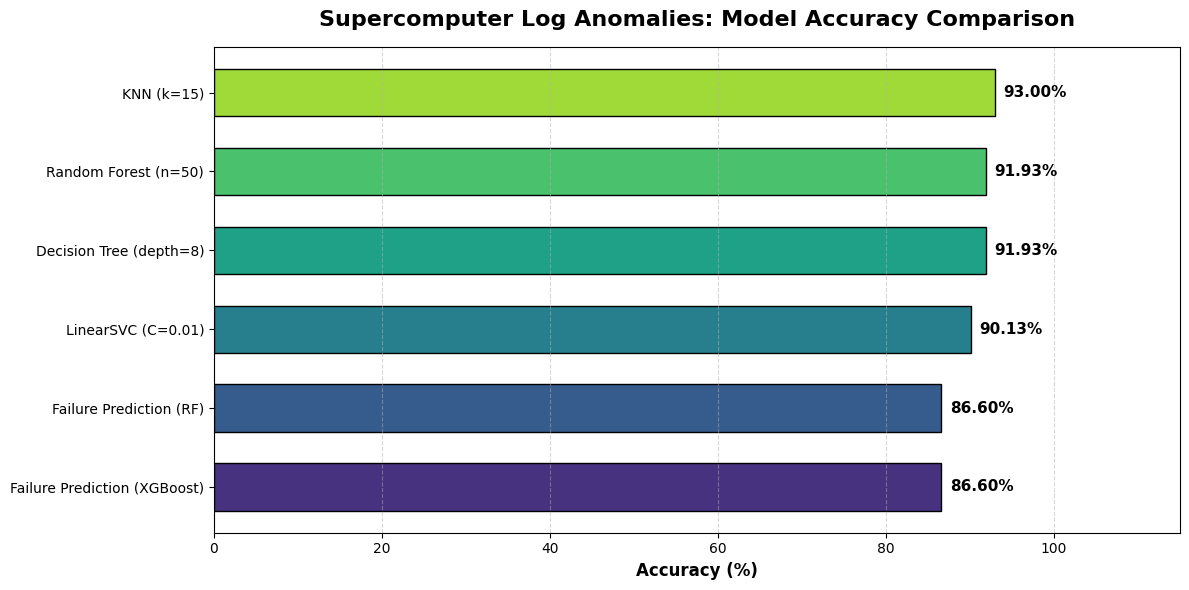

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Accuracy Visualization...")

# 1. Filter out the Unsupervised models (that have 'N/A' instead of an accuracy number)
plot_df = comparison[comparison['Accuracy'] != 'N/A'].copy()

# 2. Convert the string numbers (like '0.9945') back into Floats and turn them into %
plot_df['Accuracy'] = plot_df['Accuracy'].astype(float) * 100

# 3. Sort them so the highest accuracy is at the top of the graph!
plot_df = plot_df.sort_values('Accuracy', ascending=True)

# 4. Draw the Bar Graph
fig, ax = plt.subplots(figsize=(12, 6))

# We use the 'viridis' color palette for a hyper-professional academic look
colors = sns.color_palette("viridis", len(plot_df))
bars = ax.barh(plot_df['Model'], plot_df['Accuracy'], color=colors, edgecolor='black', height=0.6)

# 5. Stamp the exact percentage number at the end of every bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1.0, bar.get_y() + bar.get_height()/2, 
            f'{width:.2f}%', 
            ha='left', va='center', fontweight='bold', fontsize=11)

# 6. Final Polish and Formatting
ax.set_xlabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Supercomputer Log Anomalies: Model Accuracy Comparison', fontsize=16, fontweight='bold', pad=15)
ax.set_xlim(0, 115)  # We stretch the X-axis slightly past 100 so the text labels physically fit
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Generating Clustering 'Failure' Visualization...


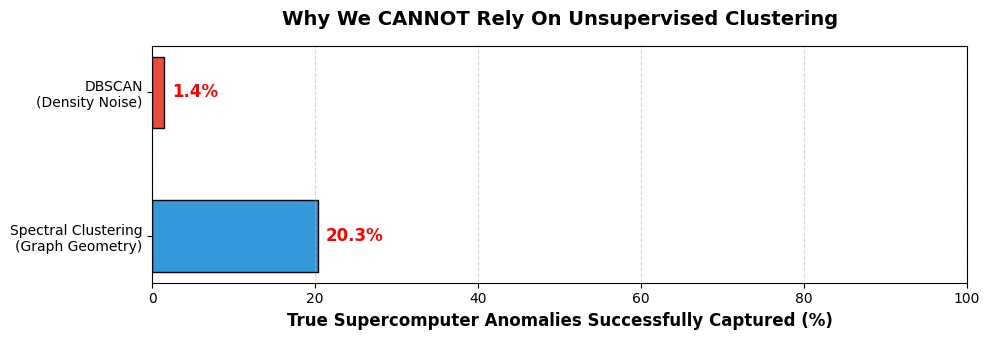

In [60]:
import matplotlib.pyplot as plt

print("Generating Clustering 'Failure' Visualization...")

# Since DBSCAN and Spectral don't have true "Accuracy", we graph their 
# "Anomaly Capture Rate" (what percentage of actual anomalies did they catch?)
# We plug in the exact numbers from the Section 7 printouts:
dbscan_capture_rate = 1.4    # Your DBSCAN noise cluster anomaly percentage
spectral_capture_rate = 20.3 # Your Spectral Cluster 1 anomaly percentage

cluster_models = ['Spectral Clustering\n(Graph Geometry)', 'DBSCAN\n(Density Noise)']
capture_rates = [spectral_capture_rate, dbscan_capture_rate]

# Draw a beautiful, compact Bar Chart
fig, ax = plt.subplots(figsize=(10, 3.5))

# We use Red and Blue to separate the two algorithms visually
bars = ax.barh(cluster_models, capture_rates, color=['#3498db', '#e74c3c'], edgecolor='black', height=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 1.0, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}%', 
            ha='left', va='center', fontweight='bold', fontsize=12, color='red')

ax.set_xlabel('True Supercomputer Anomalies Successfully Captured (%)', fontsize=12, fontweight='bold')
ax.set_title('Why We CANNOT Rely On Unsupervised Clustering', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 100) # We force the graph to 100% so the bar looks tiny and dramatic on purpose!
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---
# Functionality 4: System Monitoring
**What is System Monitoring?**  
System monitoring ties everything together by providing visual dashboards that track the health of the system over time. These visualizations let operators see patterns, spikes, and trends at a glance — when did event bursts happen? When did fatal errors spike? Where are the anomaly windows concentrated? This is the "big picture" view that makes the ML analysis actionable.

---

## Section 10 — System Monitoring Visualizations

**What we're doing:** We create three time-series visualizations that a real system administrator would use to monitor the health of the BlueGene/L supercomputer. These show event volume, error severity, and anomaly windows over the monitoring period.

In [61]:
# --- Prepare time-indexed data ---
# Group by TimeWindow for time series plots
time_agg = sequence_df.groupby('TimeWindow').agg({
    'event_count': 'sum',
    'fatal_ratio': 'mean',
    'BinaryLabel': 'max'  # 1 if any anomaly in that window
}).reset_index()

time_agg = time_agg.sort_values('TimeWindow')
print(f"Time range: {time_agg['TimeWindow'].min()} to {time_agg['TimeWindow'].max()}")
print(f"Total time windows: {len(time_agg)}")


Time range: 2005-06-03 15:40:00 to 2005-11-18 06:25:00
Total time windows: 12104


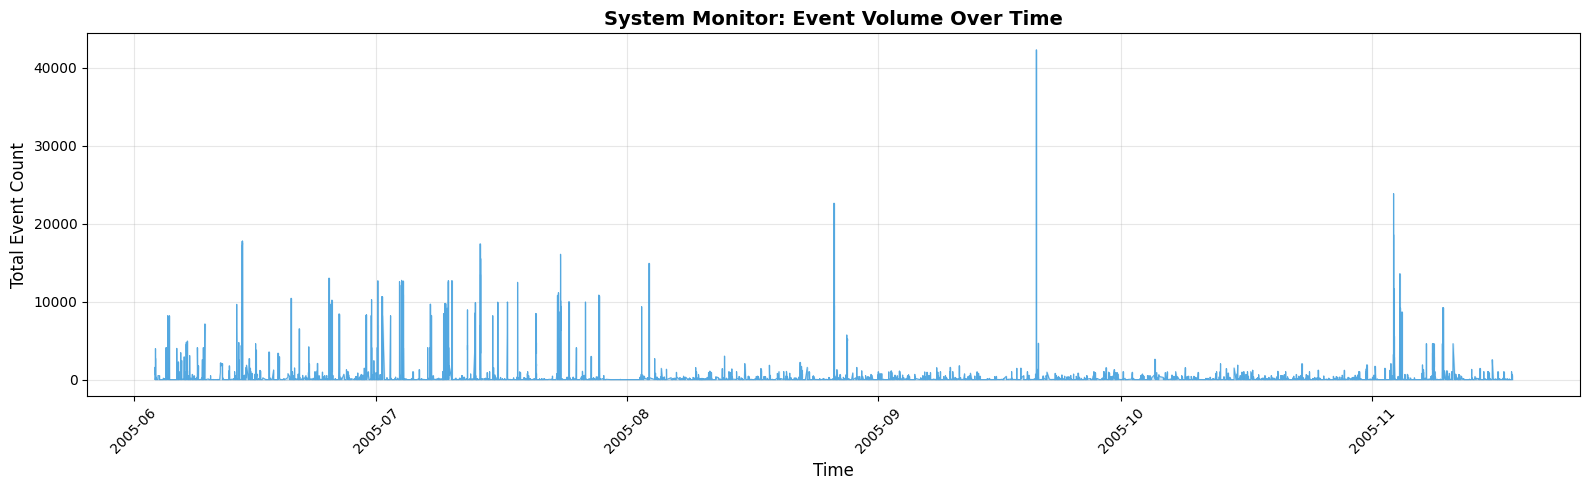

Spikes in event count often indicate bursts of activity — either heavy usage or error storms.


In [62]:
# --- Plot 1: Events over time ---
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(time_agg['TimeWindow'], time_agg['event_count'], color='#3498db', linewidth=0.8, alpha=0.8)
ax.fill_between(time_agg['TimeWindow'], time_agg['event_count'], alpha=0.2, color='#3498db')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Total Event Count', fontsize=12)
ax.set_title('System Monitor: Event Volume Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Spikes in event count often indicate bursts of activity — either heavy usage or error storms.")


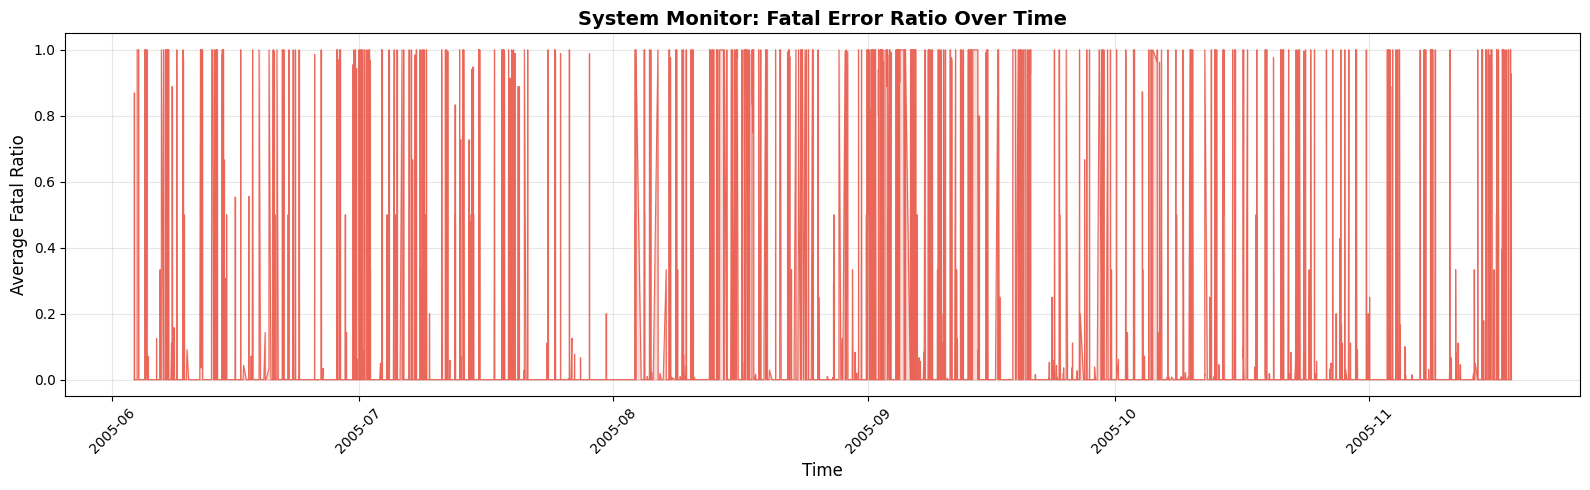

High fatal ratio periods indicate when the system was experiencing critical errors.


In [63]:
# --- Plot 2: Fatal ratio over time ---
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(time_agg['TimeWindow'], time_agg['fatal_ratio'], color='#e74c3c', linewidth=0.8, alpha=0.8)
ax.fill_between(time_agg['TimeWindow'], time_agg['fatal_ratio'], alpha=0.2, color='#e74c3c')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Average Fatal Ratio', fontsize=12)
ax.set_title('System Monitor: Fatal Error Ratio Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("High fatal ratio periods indicate when the system was experiencing critical errors.")


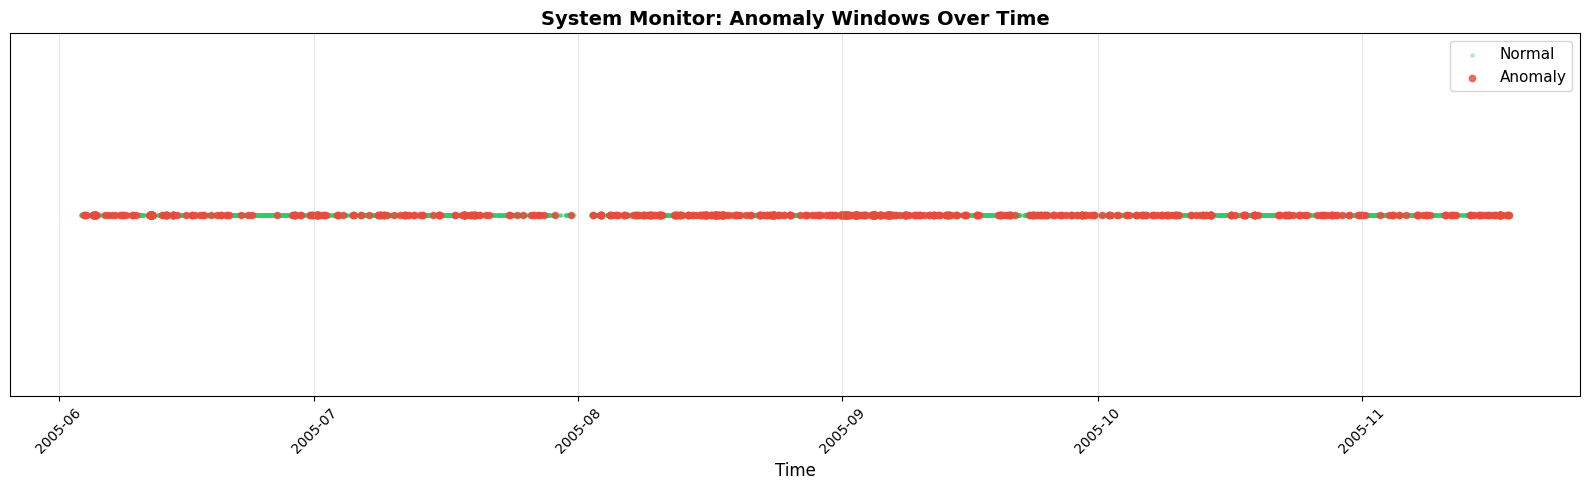

Total anomaly windows: 871 out of 12104 (7.2%)
Clusters of red dots indicate periods of sustained system issues.


In [64]:
# --- Plot 3: Anomaly windows over time ---
anomaly_windows = time_agg[time_agg['BinaryLabel'] == 1]

fig, ax = plt.subplots(figsize=(16, 5))
# Background: all time windows as light markers
ax.scatter(time_agg['TimeWindow'], [1]*len(time_agg), color='#2ecc71', alpha=0.3, s=5, label='Normal')
# Foreground: anomaly windows as red markers
ax.scatter(anomaly_windows['TimeWindow'], [1]*len(anomaly_windows), color='#e74c3c', alpha=0.8, s=20, label='Anomaly')
ax.set_xlabel('Time', fontsize=12)
ax.set_yticks([])  # Hide y-axis since it's just presence/absence
ax.set_title('System Monitor: Anomaly Windows Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f"Total anomaly windows: {len(anomaly_windows)} out of {len(time_agg)} ({len(anomaly_windows)/len(time_agg)*100:.1f}%)")
print("Clusters of red dots indicate periods of sustained system issues.")
